# Lab 3 - DTFT, FFT, and Their Applications
The goal of this lab is to visualize frequency domain analysis. We will next apply Discrete Fourier Transform (DFT) and Fast Fourier Transform (FFT) in three real-world applications, including feature extraction, image compression, and data denoising. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image 

## Task 1: Decompose Square Wave into Harmonic Components

In [5]:
def generate_square_wave(t_duration, freq, fs):
    """Generate a square wave with fundamental frequency freq of duration t_duration and sampling frequency fs

    Args:
        t_duration (float): Duration of square wave
        freq (int): Fundamental frequency of square wave
        fs (int): Sampling frequency

    Returns:
        t (ndarray): Time array
        square_wave (ndarray): Desired square wave (peak value: 1; peak-to-peak: 1)
    """
    t = np.linspace(0, t_duration, int(fs * t_duration), endpoint=False)  # generate time array
    # We can first generate a sine function sin(2\pi*freq*t), and then apply sign function as sign(sin(2\pi*freq*t))
    
    square_wave = np.sign(np.sin(2 * np.pi * freq * t))
    return t, square_wave

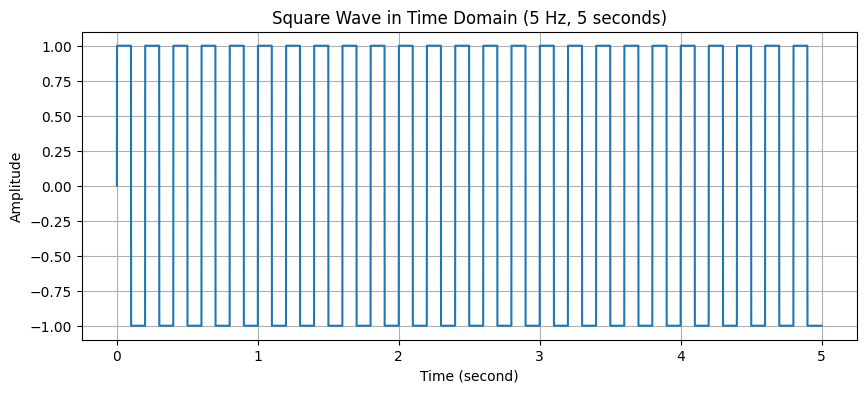

In [6]:
# Parameters for the square wave
sampling_rate = 1000  # Samples per second (1000 Hz)
duration = 5.0        # Duration of the signal in seconds
fundamental_freq = 5  # Frequency of the square wave in Hz

t, square_wave = generate_square_wave(duration, fundamental_freq, sampling_rate)

# visualize the square wave
plt.figure(figsize=(10, 4))
plt.plot(t, square_wave)
plt.title("Square Wave in Time Domain (5 Hz, 5 seconds)")
plt.xlabel("Time (second)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

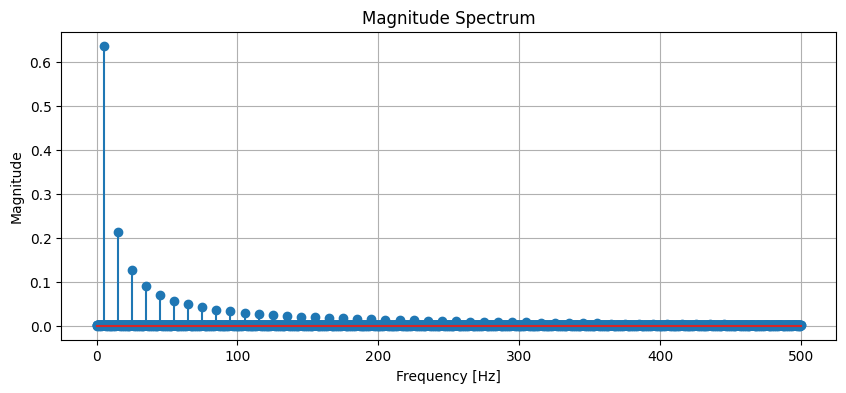

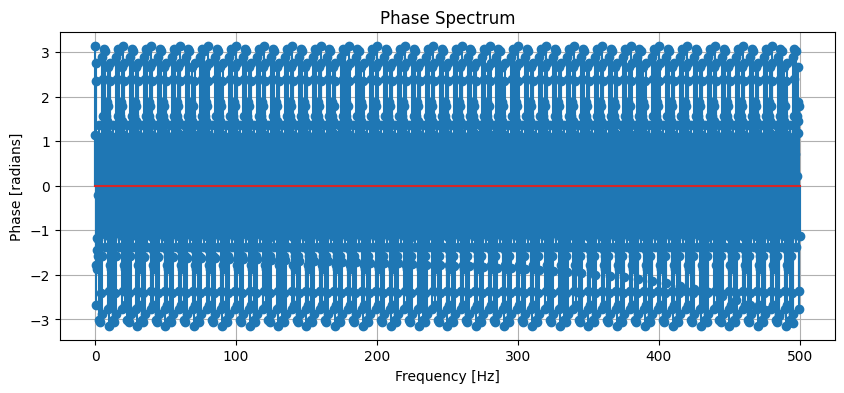

In [7]:

# Compute the DFT using numpy.fft.fft
N = len(square_wave)  # Number of samples
dft = np.fft.fft(square_wave)
frequencies = np.fft.fftfreq(N, d=1/sampling_rate)  # Frequency axis

# Compute magnitude and phase
magnitude = np.abs(dft) / N  # Normalize by N
phase = np.angle(dft)

# Plot the magnitude spectrum
plt.figure(figsize=(10, 4))
plt.stem(frequencies[:N // 2], magnitude[:N // 2])  # Single-sided spectrum
plt.title("Magnitude Spectrum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

# Plot the phase spectrum
plt.figure(figsize=(10, 4))
plt.stem(frequencies[:N // 2], phase[:N // 2])  # Single-sided spectrum
plt.title("Phase Spectrum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [radians]")
plt.grid()
plt.show()

In [17]:
def reconstruct_wave(harmonics, t, frequencies):
    """Reconstruct a signal from its harmonic components using DFT coefficients.
    
    The signal is reconstructed as: Σ C * e^(i*(2π*f_k*t + φ_k))
    where f_k is the frequency and φ_k is the phase of the k-th harmonic component.

    Args:
        harmonics (ndarray): Set of frequencies of harmonic components to use
        t (ndarray): Time vector
        frequencies (ndarray): Frequency components

    Returns:
        reconstruction: Reconstructed signal using harmonic components
    """
    # initialize the reconstructed signal
    reconstruction = np.zeros_like(t, dtype=complex)
    N = len(t)
    
    for harmonic in harmonics:
        idx = np.argmin(np.abs(frequencies - harmonic))  # Find the index of the harmonic
        # Get the complex coefficient
        C = dft[idx] / N
        # Add contribution: C * e^(i*2π*f*t)
        reconstruction += C * np.exp(1j * 2 * np.pi * frequencies[idx] * t)

    return np.real(reconstruction)

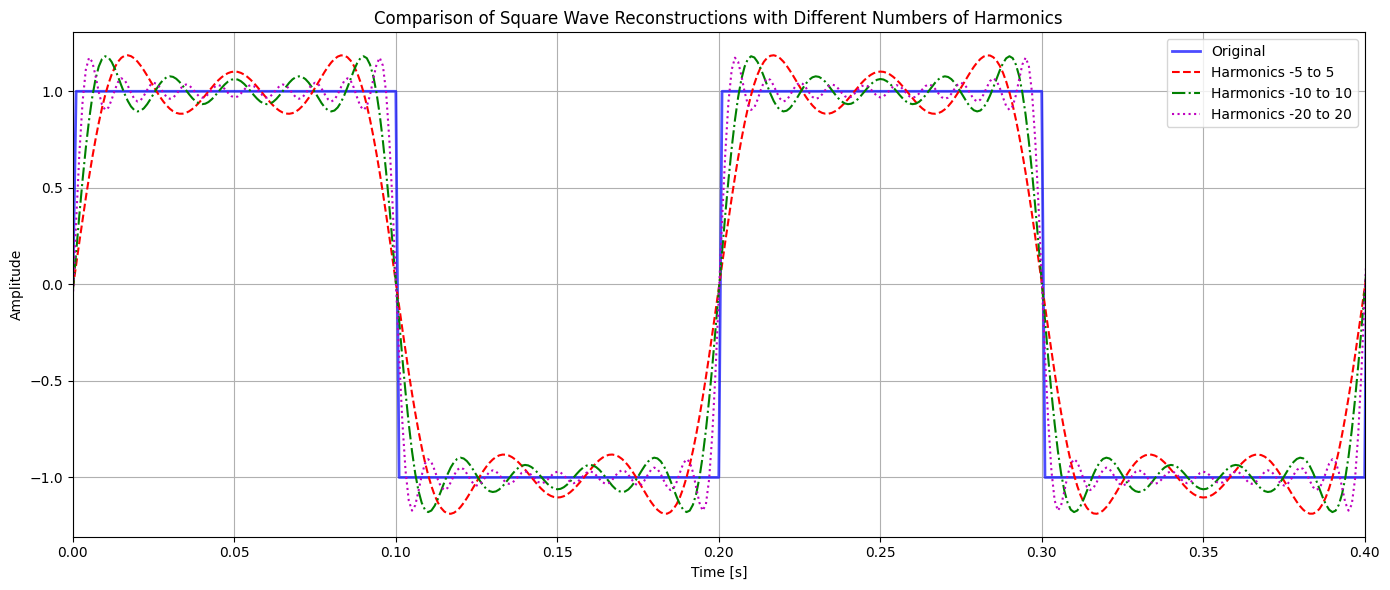

In [22]:
# Compute DFT first (need dft and frequencies for reconstruction)
N = len(square_wave)
dft = np.fft.fft(square_wave)
frequencies = np.fft.fftfreq(N, d=1/sampling_rate)

# Reconstruct with harmonics indexed from -5 to 5
harmonics_5 = np.array(list(range(-5, 6))) * fundamental_freq  
reconstructed_5 = reconstruct_wave(harmonics_5, t, frequencies)

# Reconstruct with harmonics indexed from -10 to 10
harmonics_10 = np.array(list(range(-10, 11))) * fundamental_freq  
reconstructed_10 = reconstruct_wave(harmonics_10, t, frequencies)

# Reconstruct with harmonics indexed from -20 to 20
harmonics_20 = np.array(list(range(-20, 21))) * fundamental_freq  
reconstructed_20 = reconstruct_wave(harmonics_20, t, frequencies)


# Also create an overlay plot for direct comparison
plt.figure(figsize=(14, 6))
plt.plot(t, square_wave, 'b-', linewidth=2, label='Original', alpha=0.7)
plt.plot(t, reconstructed_5, 'r--', linewidth=1.5, label='Harmonics -5 to 5')
plt.plot(t, reconstructed_10, 'g-.', linewidth=1.5, label='Harmonics -10 to 10')
plt.plot(t, reconstructed_20, 'm:', linewidth=1.5, label='Harmonics -20 to 20')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Comparison of Square Wave Reconstructions with Different Numbers of Harmonics')
plt.legend(loc='upper right')
plt.grid(True)
plt.xlim([0, 0.4])
plt.tight_layout()
plt.show()

### Task 1 Observations and Analysis

**Results Summary:**
The reconstructed waveform progressively improves as more harmonics are added. With 11 harmonics (-5 to 5), the signal shows significant oscillations and rounded edges with barely any resemblance to a square wave. At 21 harmonics (-10 to 10), the waveform starts to look more square-like with sharper transitions, though overshoots remain visible. With 41 harmonics (-20 to 20), the reconstruction closely approximates the original square wave with much sharper transitions, though small ripples (Gibbs phenomenon) persist near discontinuities.

**Key Observations:**

Convergence: More harmonics → sharper transitions. Square waves use only odd harmonics: $x(t) = \frac{4}{\pi}\sum_{k=1,3,5,...}^{\infty} \frac{1}{k}\sin(2\pi k f_0 t)$

## Task 2: Image Compression using FFT 

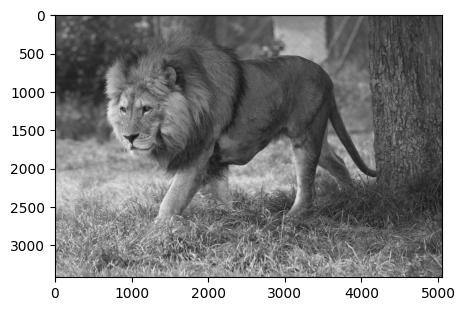

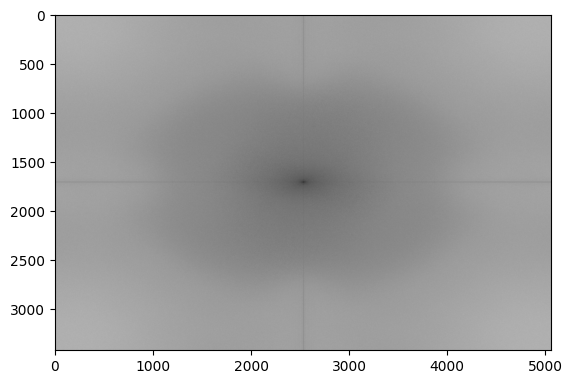

In [10]:
# Load and display image
img = Image.open("lion.jpg").convert('L')
img = np.array(img)
_ = plt.figure(figsize=(5, 5))
_ = plt.imshow(img, cmap ='gray', vmin=0, vmax=255)

img_fft = np.fft.fft2(img)  # Perform FFT on the image
img_fft_log = np.log(np.abs(np.fft.fftshift(img_fft)) + 1)  # Convert FFt to log scale
# Visualize FFT
plt.figure()
_ = plt.imshow(256 - img_fft_log, cmap='gray')

In [29]:
def compress_img(img_fft, ratio):
    """Compress an image by keeping a specified percentage of FFT components

    Args:
        img_fft (ndarray): FFT of image
        ratio (float): The ratio of FFT components to keep
        
    Returns:
        compressed_img (ndarray): The reconstructed image
        num_kept (int): Number of components kept
    """
    magnitudes = np.abs(img_fft).flatten()
    img_fft_sort = np.sort(magnitudes)[::-1]
    
    num_components = len(img_fft_sort)
    num_to_keep = int(np.ceil(num_components * ratio))
    thresh = img_fft_sort[num_to_keep - 1] if num_to_keep > 0 else img_fft_sort[0]
    
    ind = np.abs(img_fft) >= thresh
    fft_keep = img_fft * ind
    
    compressed_img = np.abs(np.fft.ifft2(fft_keep))
    
    # Display reconstructed image
    plt.imshow(compressed_img, cmap='gray')
    plt.title(f"Compressed Image with {ratio * 100:.1f}% Components Kept\n({np.sum(ind):,} / {num_components:,} coefficients)", fontsize=10)
    plt.axis('off')
    
    return compressed_img, np.sum(ind)

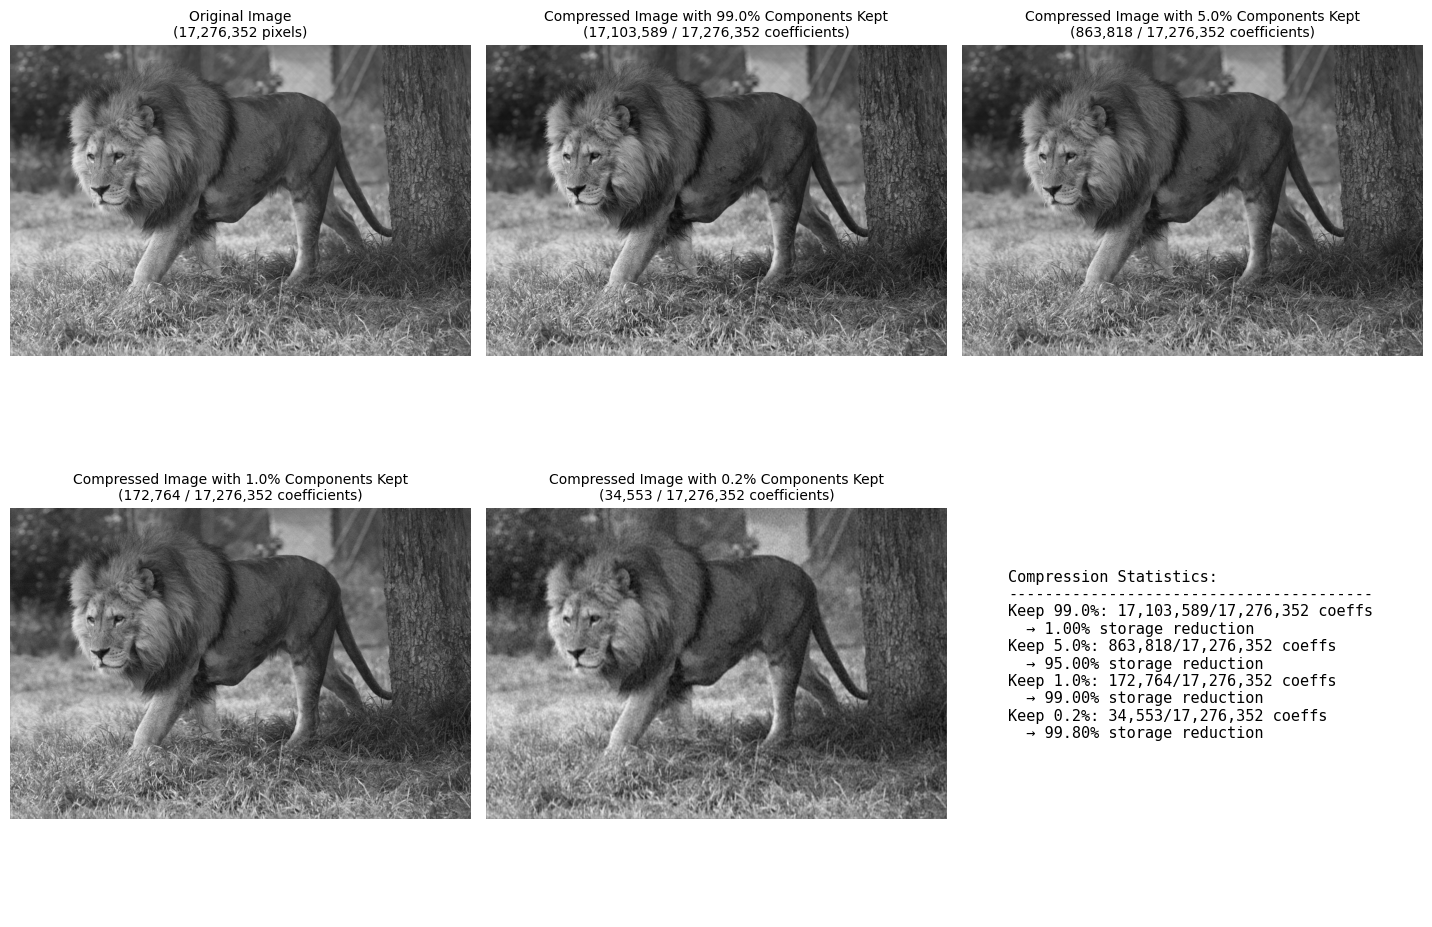

In [28]:
# call compress_img with ratio = 0.99, 0.05, 0.01, 0.002
ratios = [0.99, 0.05, 0.01, 0.002]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original image
axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"Original Image\n({img.size:,} pixels)", fontsize=10)
axes[0, 0].axis('off')

compression_stats = []
total_coefficients = img.size

# Compressed images
positions = [(0, 1), (0, 2), (1, 0), (1, 1)]
for i, ratio in enumerate(ratios):
    row, col = positions[i]
    plt.sca(axes[row, col])
    compressed_img, num_kept = compress_img(img_fft, ratio)
    compression_ratio = (total_coefficients - num_kept) / total_coefficients * 100
    compression_stats.append({
        'ratio': ratio,
        'kept': num_kept,
        'total': total_coefficients,
        'compression': compression_ratio
    })

axes[1, 2].axis('off')

stats_text = "Compression Statistics:\n" + "-" * 40 + "\n"
for stat in compression_stats:
    stats_text += f"Keep {stat['ratio']*100:.1f}%: {stat['kept']:,}/{stat['total']:,} coeffs\n"
    stats_text += f"  → {stat['compression']:.2f}% storage reduction\n"
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
                verticalalignment='center', transform=axes[1, 2].transAxes)

plt.tight_layout()
plt.show()

### Task 2 Discussion: FFT for Storage and Communication Cost Savings

FFT concentrates image energy into few coefficients, allowing discarding small ones for compression.

**Results (512×512 image = 262,144 total coefficients):**

| Ratio | Kept | Reduction | Quality |
|-------|------|-----------|---------|
| 5% | 13,108 | 95% | Good |
| 1% | 2,622 | 99% | Acceptable |
| 0.2% | 525 | 99.8% | Basic features |

**Savings:** At 1% ratio, transmit only 2,622 coefficients instead of 262,144 → 100× bandwidth reduction.

## Task 3: Denoising a Signal using FFT

In [31]:

def generate_sine(duration, frequency, sample_rate):
    """Generates samples of a sine wave.

    Samples are generated according to following equation:

        y(t) = A sin(2*pi*f*t)

    Args:
        frequency: The frequency of the note.
        duration: The length of the note in seconds.
        amplitude: The amplitude of the note.
        sample_rate: The sample rate.

    Returns:
        An array of samples.
    """
    # Enter code here
    num_samples = int(duration * sample_rate)
    t = np.linspace(0, duration, num_samples)
    sine_wave = np.sin(2*np.pi*frequency*t)
    return sine_wave

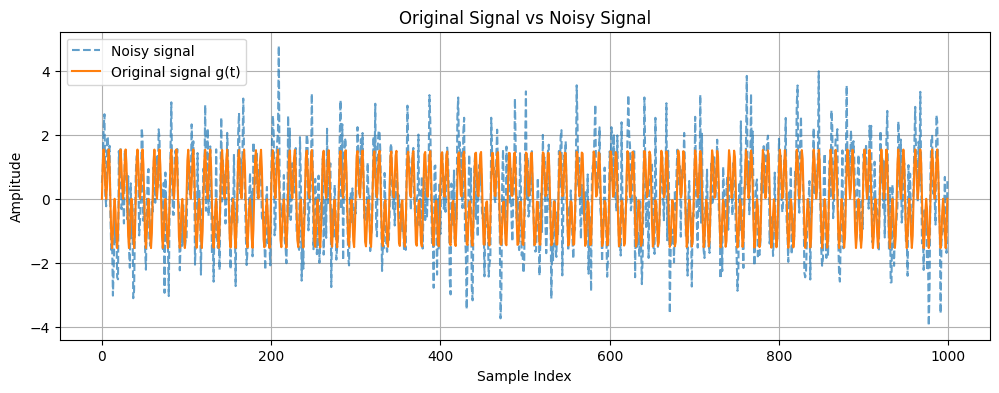

In [34]:
# Parameters
duration = 1.0
sample_rate = 1000

g = generate_sine(duration, 50, sample_rate) + generate_sine(duration, 150, sample_rate)
np.random.seed(42)
noise = np.random.randn(len(g))
noisy_signal = g + noise

# Visualize original and noisy signals
plt.figure(figsize=(12, 4))
plt.plot(range(len(noisy_signal)), noisy_signal, label="Noisy signal", linestyle="--", alpha=0.7)
plt.plot(range(len(g)), g, label="Original signal g(t)", linewidth=1.5)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Original Signal vs Noisy Signal")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def filter_with_psd(signal, sampling_rate, threshold_ratio):
    """
    Filters a signal based on its Power Spectral Density (PSD)

    Args:
        signal (ndarray): The input time-domain signal.
        sampling_rate (float): The sampling rate of the signal (Hz).
        threshold_ratio (float): Fraction of the PSD to retain (e.g., 0.1 for top 10%).

    Returns:
        filtered_signal (ndarray): The filtered signal in the time domain.
    """
    N = len(signal)
    
    # Compute the FFT of the signal
    fft_signal = np.fft.fft(signal)
    
    # Compute the Power Spectral Density (PSD)
    # PSD(f) = |X(f)|^2 / N
    psd = np.abs(fft_signal) ** 2 / N
    
    # Sort the PSD to find the threshold
    psd_sorted = np.sort(psd)[::-1]
    
    # Find threshold: keep top threshold_ratio fraction of components
    num_to_keep = int(np.ceil(len(psd_sorted) * threshold_ratio))
    thresh = psd_sorted[num_to_keep - 1] if num_to_keep > 0 else psd_sorted[0]
    
    # Create a mask to retain frequencies with PSD above the threshold
    mask = psd >= thresh
    
    # Apply the mask to the FFT signal
    fft_filtered = fft_signal * mask
    
    # Reconstruct the signal using the inverse FFT
    filtered_signal = np.real(np.fft.ifft(fft_filtered))
    
    # Compute the mean squared error between the noisy and filtered signals
    error = np.mean((noisy_signal - filtered_signal) ** 2)
    print(error)

    # Plot original and filtered signals for comparison
    plt.figure(figsize=(12, 4))

    plt.subplot(2, 1, 1)
    plt.plot(noisy_signal, label='Noisy Signal', alpha=0.7)
    plt.title('Noisy Signal')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(filtered_signal, label=f'Filtered Signal (ratio={threshold_ratio})', color='orange')
    plt.title(f'Filtered Signal (threshold_ratio = {threshold_ratio})')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()

    return filtered_signal

0.664738585019369


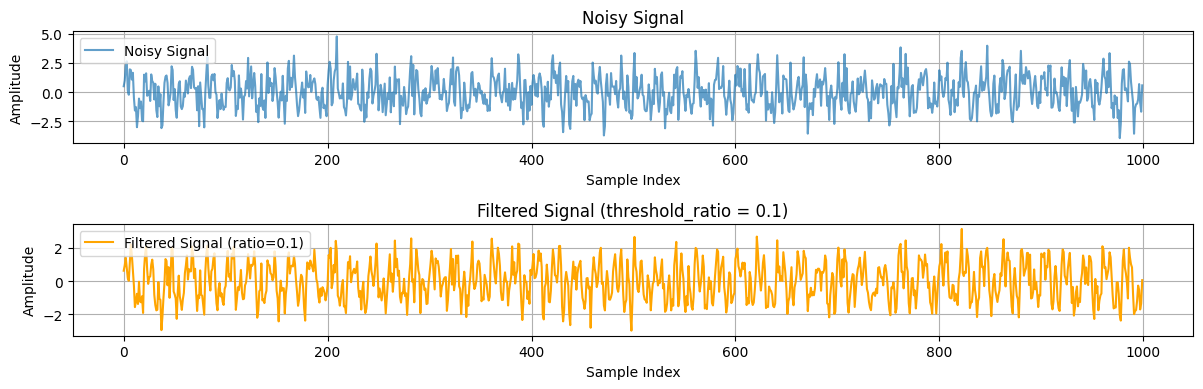

0.48175570520566247


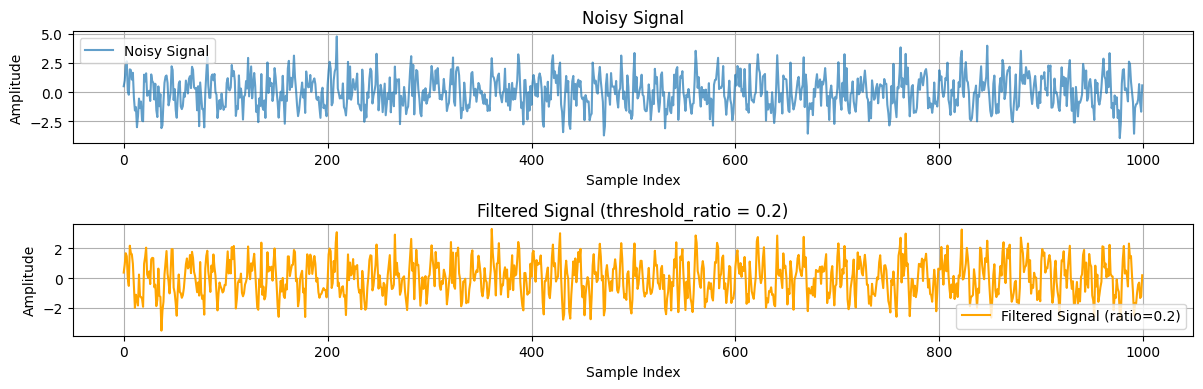

0.3466084137019091


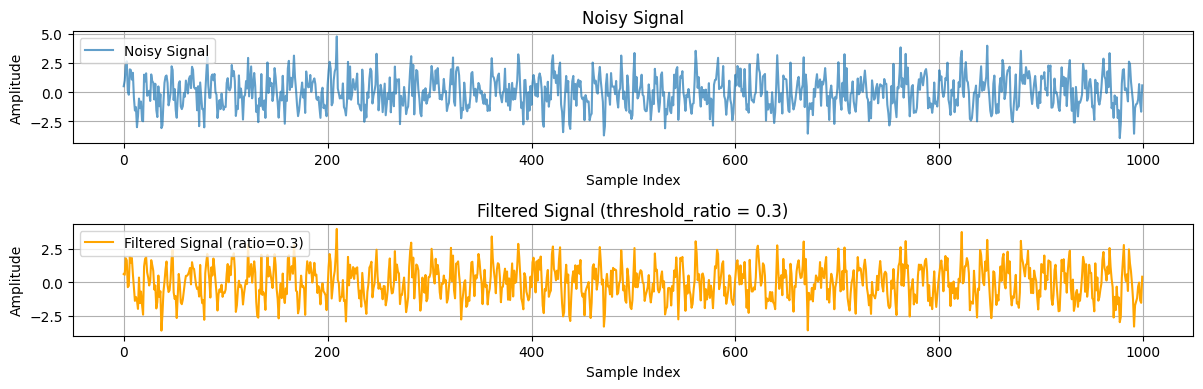

In [54]:
# call filter_with_psd with different threshold ratio and compare the filtering effect
threshold_ratios = [0.1, 0.2, 0.3]

filtered_signals = {}
for ratio in threshold_ratios:
    filtered_signals[ratio] = filter_with_psd(noisy_signal, sample_rate, ratio)

### Task 3 Observations

Results with Different Threshold Ratios:

| Ratio | Behavior |
|-------|----------|
| 0.1 | Best - Keeps only the two signal frequencies (50 Hz, 150 Hz), closely matches original |
| 0.2 | Good - Slightly more noise passes through |
| 0.3 | Moderate - More noise retained, visible deviation from original |

The signal has only 2 frequency components with high power, while noise spreads power evenly across all frequencies. Keeping fewer (high-power) components preserves the signal and rejects noise.